# Superstore Sales & Profit Analysis
## Exploratory Data Analysis of retail sales, profitability, customer segments, and discount impact using Python.
### Business Questions:
1. Which categories generate the highest sales and profit?
2. Which products or sub-categories are underperforming?
3. How do discounts affect profitability?
4. Which customer segments and regions are most profitable?
5. What actionable business insights can be derived?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Load Dataset

In [2]:
df = pd.read_csv("Superstore.csv", encoding="latin1")

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Data Cleaning

-- Verify missing values and data types

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## KPI Overview
### Initial business overview

In [6]:
print("Total Sales:", round(df['Sales'].sum(), 2))
print("Total Profit:", round(df['Profit'].sum(), 2))
print("Average Discount:", round(df['Discount'].mean(), 2))
print("Total Orders:", df['Order ID'].nunique())
print("Total Customers:", df['Customer ID'].nunique())

Total Sales: 2297200.86
Total Profit: 286397.02
Average Discount: 0.16
Total Orders: 5009
Total Customers: 793


## Sales by Category

In [7]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

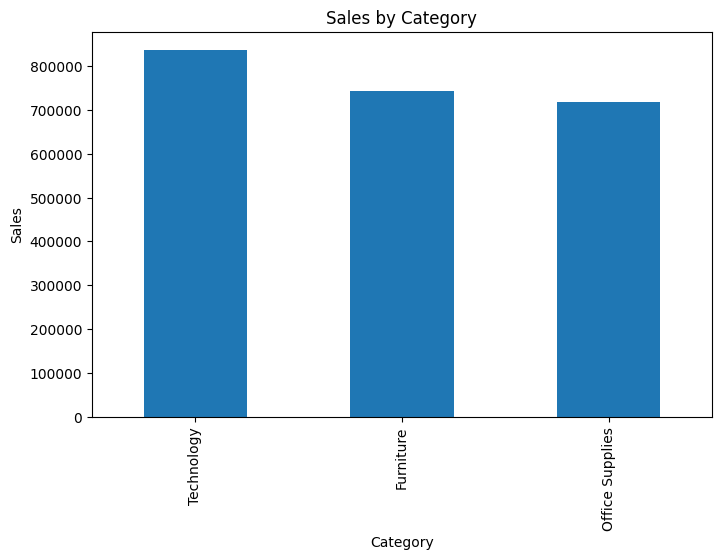

In [8]:
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.ylabel('Sales')
plt.show()

### Insight:
Technology generated the highest total sales among all categories.
Although Furniture sales are relatively high, its profitability is significantly weaker, suggesting higher operational or discount costs.


## Profit by Category

In [9]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

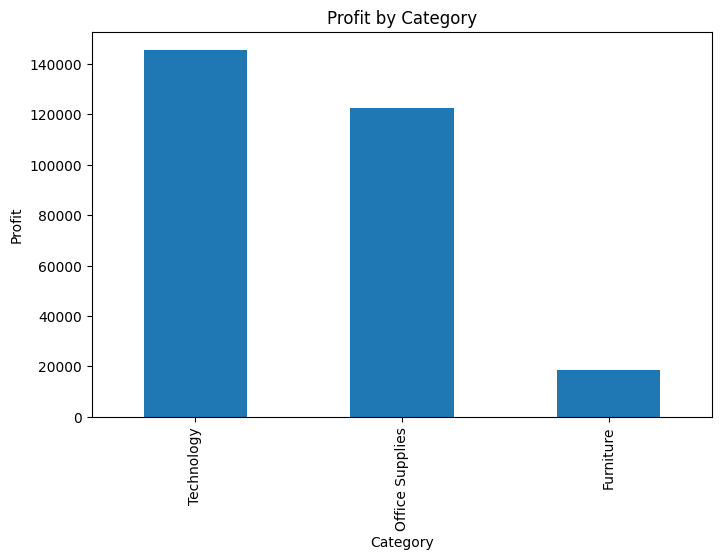

In [10]:
plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')
plt.title('Profit by Category')
plt.ylabel('Profit')
plt.show()

### Insight:
Furniture generates strong revenue but relatively low profit.

This indicates potential issues such as:
- heavy discounting
- shipping costs
- low profit margins

## Profit by Sub-Category

In [11]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

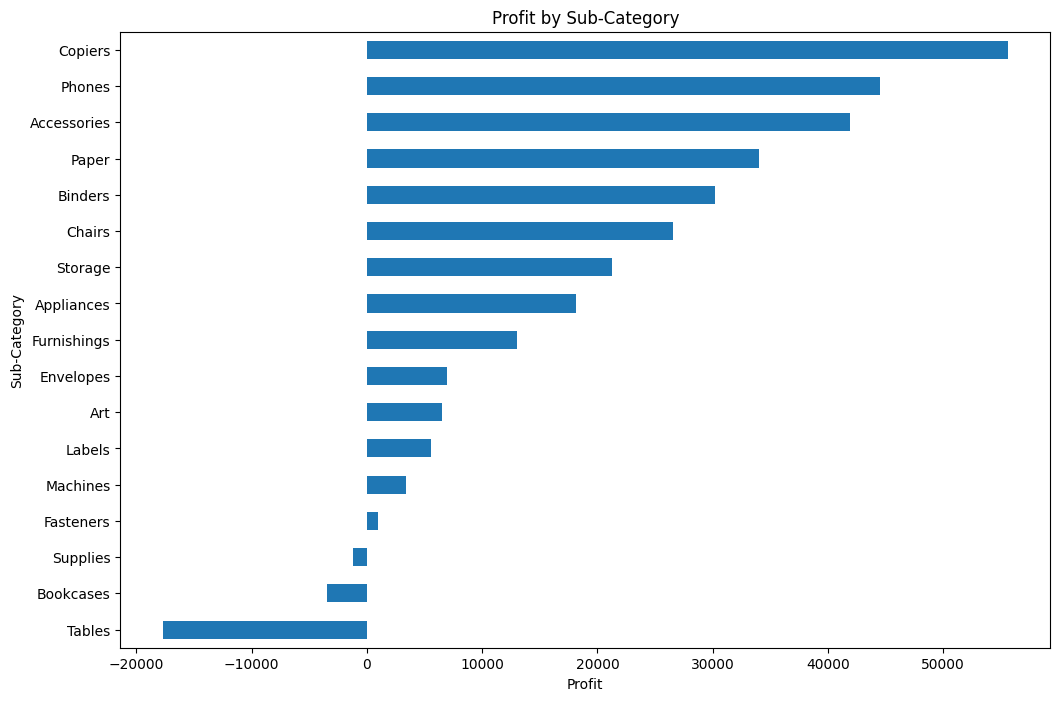

In [12]:
plt.figure(figsize=(12,8))
sub_profit.plot(kind='barh')
plt.title('Profit by Sub-Category')
plt.xlabel('Profit')
plt.show()

### Key Finding:

Tables and Bookcases are generating negative profit.

Despite reasonable sales volume,
these products are causing financial losses.

Potential reasons:
- excessive discounting
- logistics costs
- poor pricing strategy

## Regional Performance

In [13]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

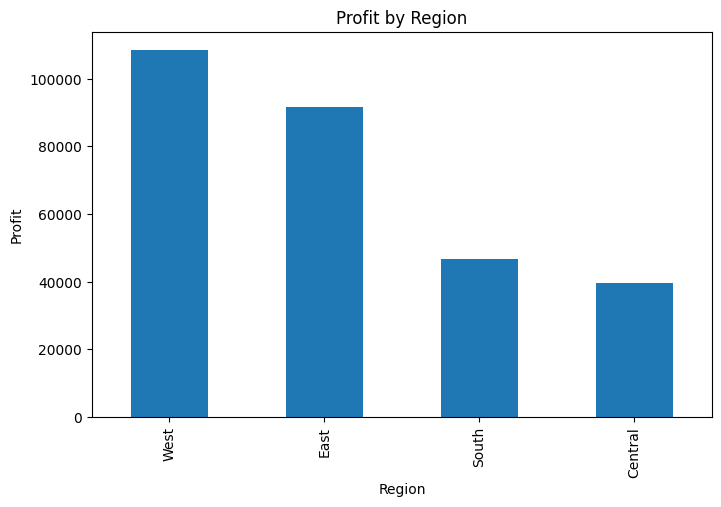

In [14]:
plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')
plt.title('Profit by Region')
plt.ylabel('Profit')
plt.show()

### Insight:

The West and East regions are the strongest profit contributors.

Central region significantly underperforms,
indicating possible operational inefficiencies
or weaker market conditions.

## Customer Segment Analysis

In [15]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

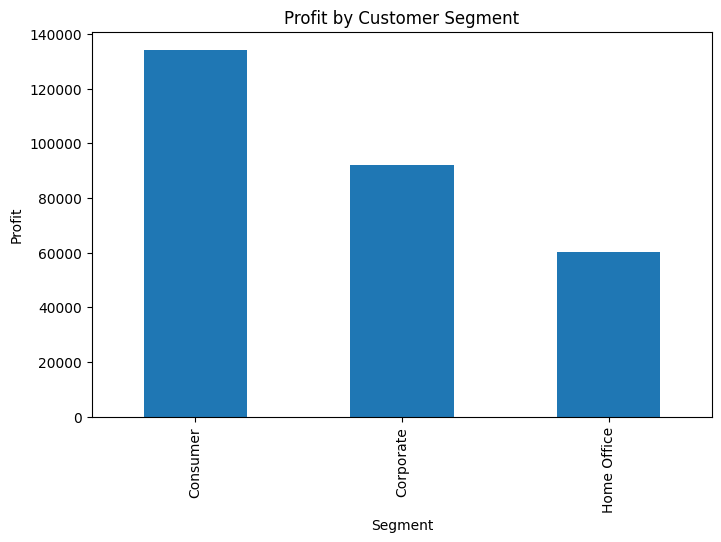

In [16]:
plt.figure(figsize=(8,5))
segment_profit.plot(kind='bar')
plt.title('Profit by Customer Segment')
plt.ylabel('Profit')
plt.show()

### Insight:

Consumer customers contribute the highest profit.

Home Office segment performs the weakest,
suggesting lower purchasing volume or weaker margins.

## Discount vs Profit

### Correlation

In [17]:
correlation = df[['Discount', 'Profit']].corr()
print(correlation)

          Discount    Profit
Discount  1.000000 -0.219487
Profit   -0.219487  1.000000


### Scatter Plot

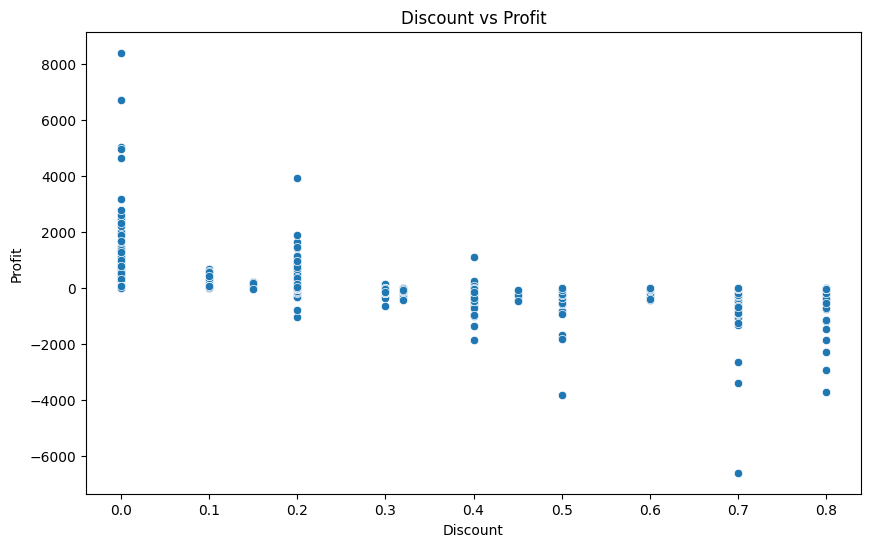

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.title('Discount vs Profit')
plt.show()

### Insight:

The scatter plot shows a clear negative relationship
between discount and profit.

Orders with little or no discount tend to generate
higher profits, while heavily discounted orders
frequently result in losses.

The correlation coefficient (-0.22) confirms that
higher discounts generally reduce profitability.

This suggests the company may be relying too heavily
on aggressive discount strategies, which can hurt
overall business performance.

## Top 10 Products by Sales

In [19]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

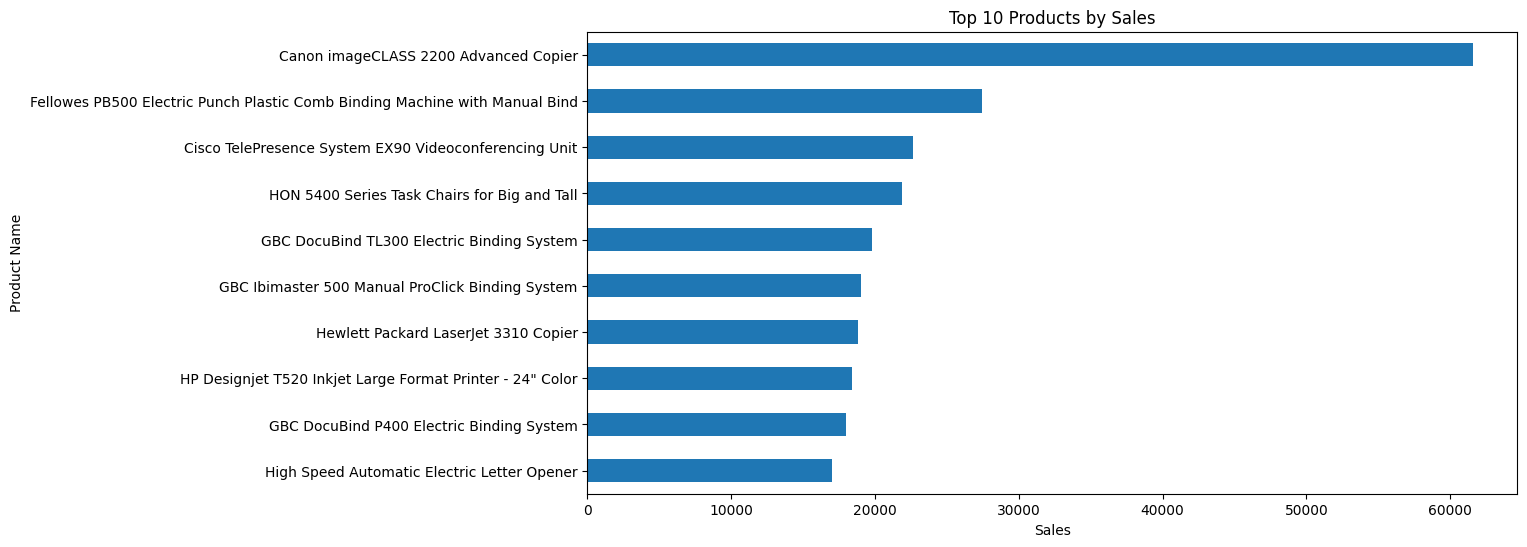

In [20]:
plt.figure(figsize=(12,6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.show()

### Insight:

A small number of products contribute disproportionately high sales.

This suggests product concentration risk,
where revenue heavily depends on several key products.

## Profit Margin

In [21]:
df['Profit Margin'] = df['Profit'] / df['Sales']

In [22]:
print(df['Profit Margin'].describe())

count    9994.000000
mean        0.120314
std         0.466754
min        -2.750000
25%         0.075000
50%         0.270000
75%         0.362500
max         0.500000
Name: Profit Margin, dtype: float64


# Final Conclusion

1. Technology is the most profitable category overall.
2. Furniture has high sales but weak profitability.
3. Tables and Bookcases consistently generate losses.
4. Excessive discounts strongly reduce profit margins.
5. West and East regions outperform other regions.
6. Consumer segment contributes the largest share of profit.

## Business Recommendations:
- Reduce excessive discounting
- Reevaluate pricing strategy for loss-making products
- Focus marketing on high-margin categories
- Improve performance in underperforming regions

In [23]:
df.to_csv("superstore_cleaned.csv", index=False)